# Noise False Detections

### Read individual .csv files with predictions and store as one single .csv

In [9]:
import os
from pathlib import Path
import glob
import sys
import time
from datetime import datetime
import pandas as pd
import numpy as np
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

# Base path: where to gather the outputs from
# csv output path: where to store the combined csv
base_path = "../results/csv/" 
subdir = "/bm_noise_only"
subdir_name = subdir.strip("/")

csv_output_path = os.path.join(base_path, "combined")
csv_output_name = f"{subdir_name}_full.csv"

# Match filenames to only get the csv outputs
files = list(Path(base_path, subdir_name).rglob("*.csv"))

# Sort files by timechunk folder name (0 = station, 1 = timechunk)
files = sorted(files, key=lambda x:x.parents[1].name)

# Load only the second physical row from each csv (first data row); skip header-only files
rows = []
skipped_files = []
for file in files:
    file_df = pd.read_csv(file)
    if len(file_df) > 0:
        rows.append(file_df.iloc[[0]])
    else:
        skipped_files.append(file)

df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

# Extract raw datetime string from time window directories
pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(pattern)

# Convert to datetime and insert into dataframe
df["start_dt"] = pd.to_datetime(matches["start_dt"], format="%Y%m%dT%H%M%SZ")
df["end_dt"] = pd.to_datetime(matches["end_dt"], format="%Y%m%dT%H%M%SZ")

# Insert correct network code
df["network"] = df["file_name"].str.extract(r'/(.*?)\.')

# Filter out rows with NaN for both p_probability and s_probability (no predicted picks)
#df = df[df["p_probability"].notna() | df["s_probability"].notna()]

# Save dataframe to csv
os.makedirs(csv_output_path, exist_ok=True)
combined_path = os.path.join(csv_output_path, csv_output_name)
df.to_csv(combined_path, index=False)

# Print some basic information about the number of predicted picks
num_rows = len(df)
num_files = len(files)
num_p_picks = sum(df["p_probability"].notna())
num_s_picks = sum(df["s_probability"].notna())
num_negatives = sum(df["p_probability"].isna() & df["s_probability"].isna())

print(f"Read {num_rows} predictions from {num_files} files.")
print(f"Skipped {len(skipped_files)} header-only files.")
print(f"Number of p-arrivals: {num_p_picks}\nNumber of s-arrivals: {num_s_picks}")
print(f"Number of empty predictions: {num_negatives}")

Read 1896 predictions from 2004 files.
Skipped 108 header-only files.
Number of p-arrivals: 1033
Number of s-arrivals: 32
Number of empty predictions: 862


### Plot false-pick probability distributions from the combined noise file

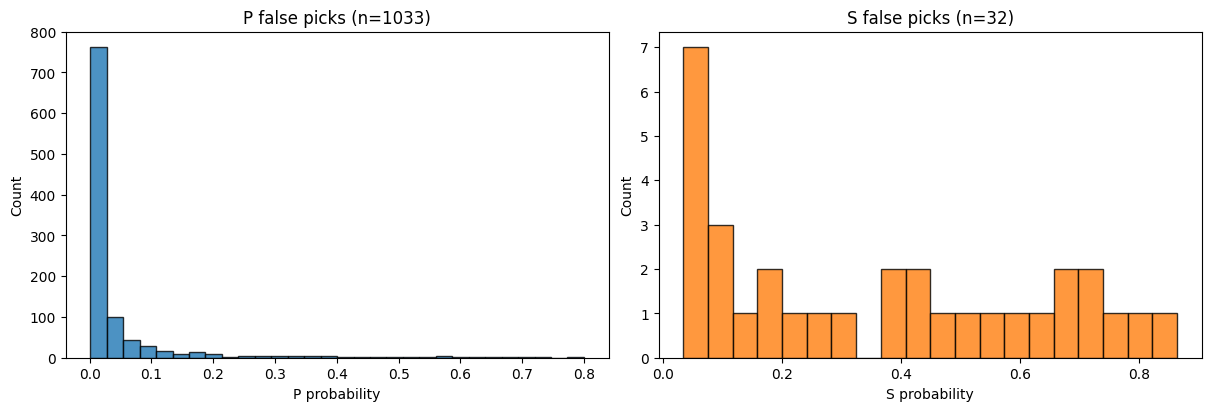

,p_probability
count,1033.000000
mean,0.042935
std,0.102765
min,0.001000
25%,0.003000
50%,0.008000
75%,0.030000
max,0.800000


,s_probability
count,32.000000
mean,0.358031
std,0.269013
min,0.034000
25%,0.098250
50%,0.349000
75%,0.590750
max,0.864000


In [10]:
# Reload combined noise predictions and keep only false picks with a reported probability
combined_path = os.path.join(csv_output_path, csv_output_name)
combined_df = pd.read_csv(combined_path, parse_dates=["start_dt", "end_dt"])

p_false = combined_df.loc[combined_df["p_probability"].notna(), ["station", "start_dt", "p_probability"]].copy()
s_false = combined_df.loc[combined_df["s_probability"].notna(), ["station", "start_dt", "s_probability"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].hist(p_false["p_probability"], bins=30, color="tab:blue", alpha=0.8, edgecolor="black")
axes[0].set_title(f"P false picks (n={len(p_false)})")
axes[0].set_xlabel("P probability")
axes[0].set_ylabel("Count")

axes[1].hist(s_false["s_probability"], bins=20, color="tab:orange", alpha=0.8, edgecolor="black")
axes[1].set_title(f"S false picks (n={len(s_false)})")
axes[1].set_xlabel("S probability")
axes[1].set_ylabel("Count")

plt.show()

display(p_false["p_probability"].describe().to_frame(name="p_probability"))
display(s_false["s_probability"].describe().to_frame(name="s_probability"))

### Print false picks with probability greater than set threshold

In [11]:
prob_threshold = 0.2

p_high = combined_df.loc[
    combined_df["p_probability"].fillna(0) > prob_threshold,
    ["station", "network", "file_name", "start_dt", "end_dt", "p_arrival_time", "p_probability"]
].sort_values("p_probability", ascending=False)

s_high = combined_df.loc[
    combined_df["s_probability"].fillna(0) > prob_threshold,
    ["station", "network", "file_name", "start_dt", "end_dt", "s_arrival_time", "s_probability"]
].sort_values("s_probability", ascending=False)

print(f"P false picks with probability > {prob_threshold}: {len(p_high)}")
display(p_high)

print(f"S false picks with probability > {prob_threshold}: {len(s_high)}")
display(s_high)

P false picks with probability > 0.2: 54


,station,network,file_name,start_dt,end_dt,p_arrival_time,p_probability
1802,NIF,HE,NIF/HE.NIF..HHE__20250113T053234Z__20250113T05...,2025-01-13 05:32:34,2025-01-13 05:33:34,2025-01-13 05:32:38.732000,0.800
541,FIB2,HE,FIB2/HE.FIB2..HHN__20250105T135350Z__20250105T...,2025-01-05 13:53:50,2025-01-05 13:54:50,2025-01-05 13:53:54.870000,0.734
1558,HEL1,HE,HEL1/HE.HEL1..HHZ__20250111T142210Z__20250111T...,2025-01-11 14:22:10,2025-01-11 14:23:10,2025-01-11 14:22:14.936000,0.729
813,KORF,HE,KORF/HE.KORF..CHN__20250107T030032Z__20250107T...,2025-01-07 03:00:32,2025-01-07 03:01:32,2025-01-07 03:00:36.774000,0.708
1026,VUOS,HE,VUOS/HE.VUOS..HHE__20250108T075019Z__20250108T...,2025-01-08 07:50:19,2025-01-08 07:51:19,2025-01-08 07:50:22.220000,0.686
257,OUF,HE,OUF/HE.OUF..HHZ__20250103T224357Z__20250103T22...,2025-01-03 22:43:57,2025-01-03 22:44:57,2025-01-03 22:44:01.750000,0.682
674,TRE03,HE,TRE03/HE.TRE03..CHZ__20250106T085431Z__2025010...,2025-01-06 08:54:31,2025-01-06 08:55:31,2025-01-06 08:54:36.204000,0.657
444,KIF,HE,KIF/HE.KIF..HHE__20250104T233437Z__20250104T23...,2025-01-04 23:34:37,2025-01-04 23:35:37,2025-01-04 23:34:41.050000,0.655
1603,RSUO,HE,RSUO/HE.RSUO..HHZ__20250111T233550Z__20250111T...,2025-01-11 23:35:50,2025-01-11 23:36:50,2025-01-11 23:35:54.192000,0.633
1354,OBF0,HE,OBF0/HE.OBF0..HHN__20250110T071337Z__20250110T...,2025-01-10 07:13:37,2025-01-10 07:14:37,2025-01-10 07:13:41.336000,0.632


S false picks with probability > 0.2: 19


,station,network,file_name,start_dt,end_dt,s_arrival_time,s_probability
1324,KIF,HE,KIF/HE.KIF..HHN__20250110T020346Z__20250110T02...,2025-01-10 02:03:46,2025-01-10 02:04:46,2025-01-10 02:03:58.570000,0.864
674,TRE03,HE,TRE03/HE.TRE03..CHZ__20250106T085431Z__2025010...,2025-01-06 08:54:31,2025-01-06 08:55:31,2025-01-06 08:54:41.194000,0.784
376,KU6,HE,KU6/HE.KU6..HHZ__20250104T140313Z__20250104T14...,2025-01-04 14:03:13,2025-01-04 14:04:13,2025-01-04 14:03:34.230000,0.748
813,KORF,HE,KORF/HE.KORF..CHN__20250107T030032Z__20250107T...,2025-01-07 03:00:32,2025-01-07 03:01:32,2025-01-07 03:00:47.564000,0.729
1454,OUF,HE,OUF/HE.OUF..HHE__20250110T231330Z__20250110T23...,2025-01-10 23:13:30,2025-01-10 23:14:30,2025-01-10 23:13:33.900000,0.721
1425,KU1,HE,KU1/HE.KU1..SHE__20250110T182358Z__20250110T18...,2025-01-10 18:23:58,2025-01-10 18:24:58,2025-01-10 18:24:21.968000,0.663
1026,VUOS,HE,VUOS/HE.VUOS..HHE__20250108T075019Z__20250108T...,2025-01-08 07:50:19,2025-01-08 07:51:19,2025-01-08 07:50:23.460000,0.661
854,OUF,HE,OUF/HE.OUF..HHN__20250107T084153Z__20250107T08...,2025-01-07 08:41:53,2025-01-07 08:42:53,2025-01-07 08:42:11.450000,0.632
1558,HEL1,HE,HEL1/HE.HEL1..HHZ__20250111T142210Z__20250111T...,2025-01-11 14:22:10,2025-01-11 14:23:10,2025-01-11 14:22:30.286000,0.577
1876,KIF,HE,KIF/HE.KIF..HHE__20250113T164507Z__20250113T16...,2025-01-13 16:45:07,2025-01-13 16:46:07,2025-01-13 16:45:22.880000,0.561


### Plot waveforms for the highest-probability false P and S picks

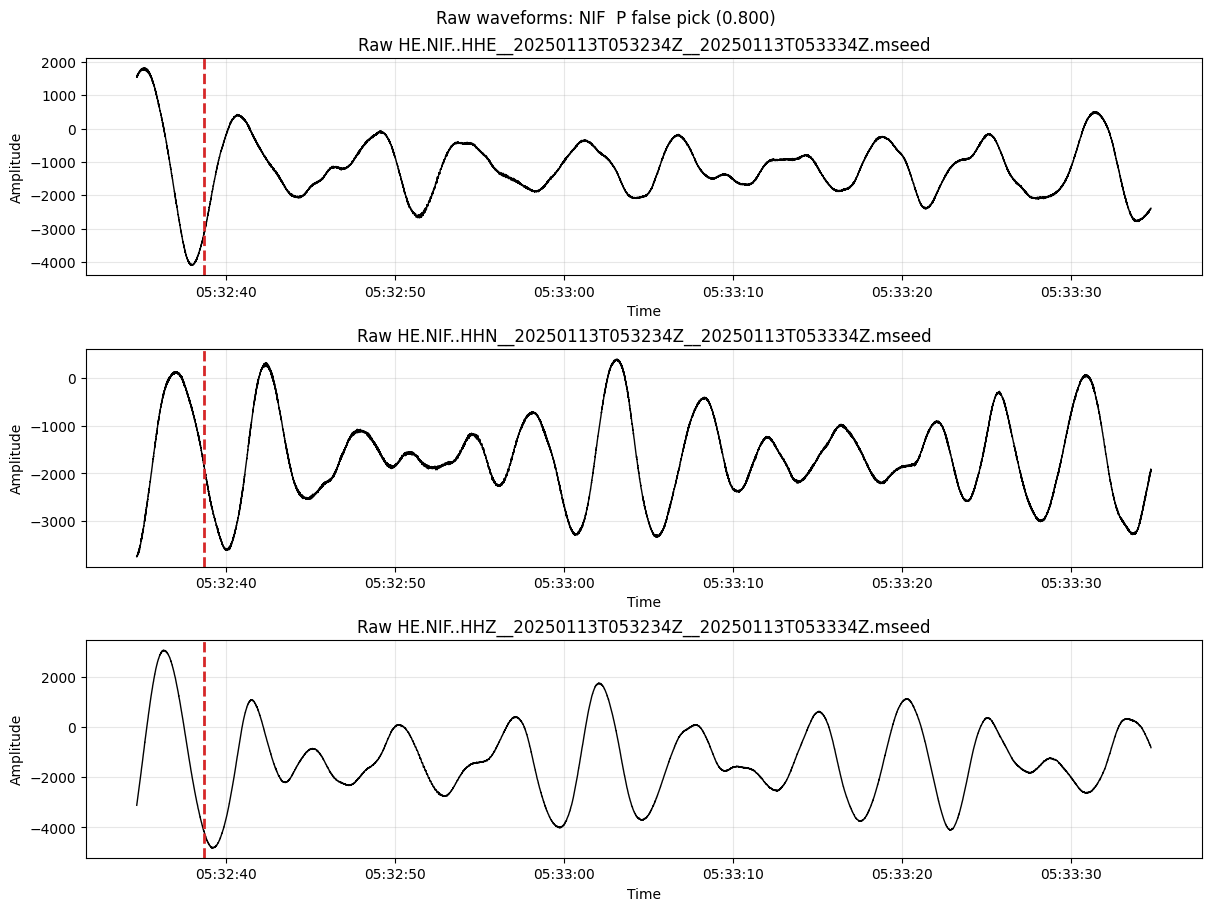

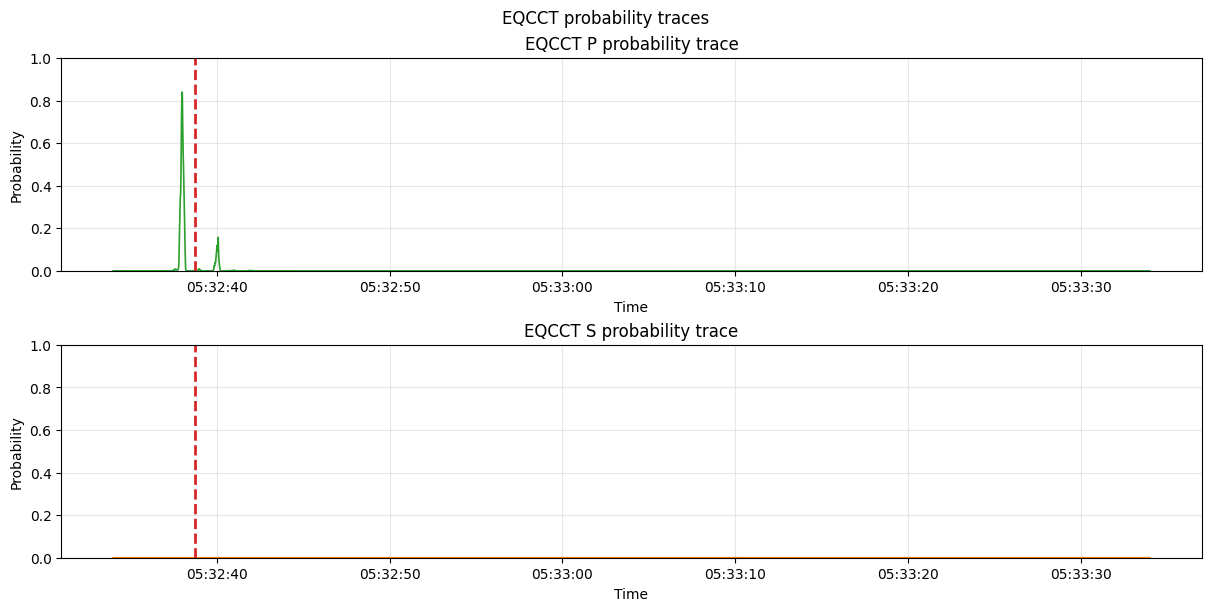

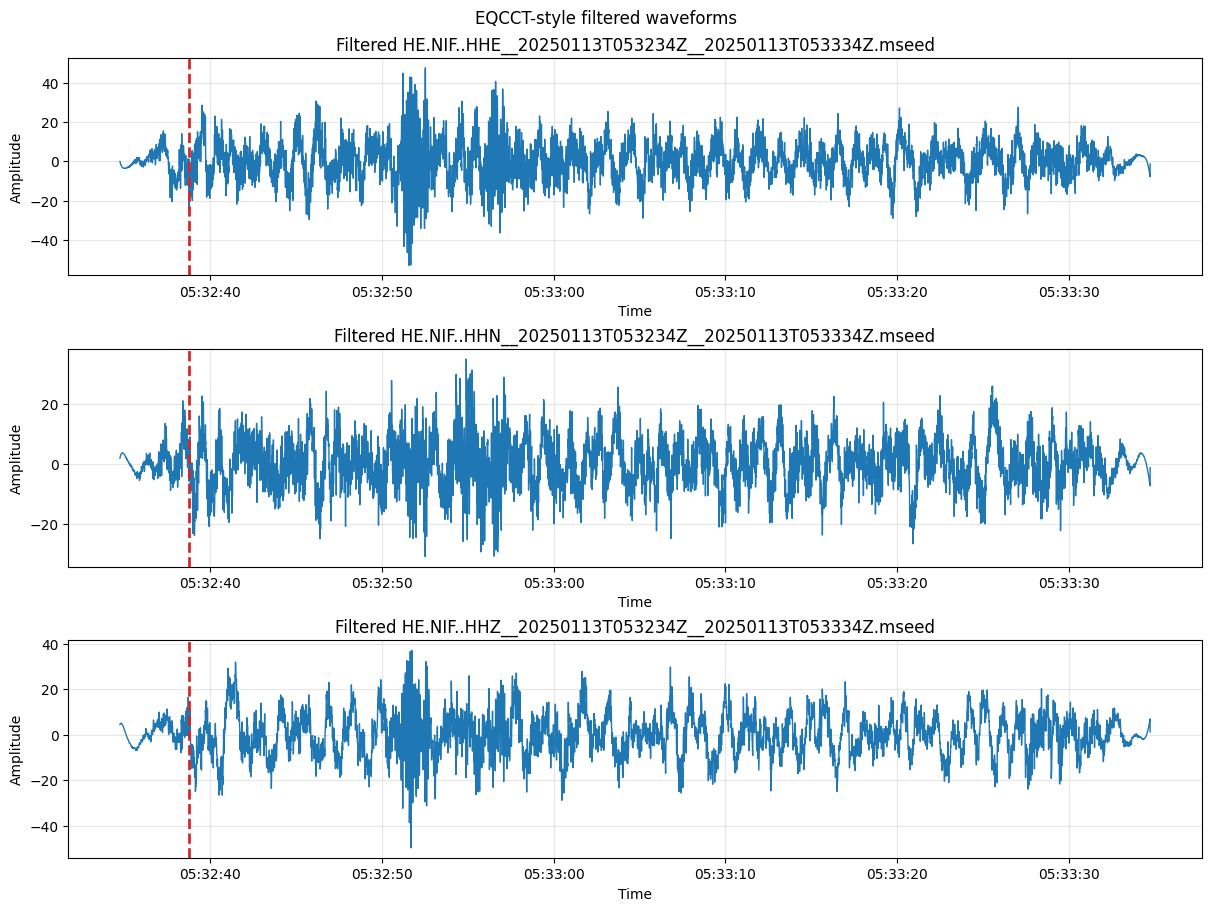

,file_name,network,station,instrument_type,station_lat,station_lon,station_elv,p_arrival_time,p_probability,s_arrival_time,s_probability,start_dt,end_dt
1802,NIF/HE.NIF..HHE__20250113T053234Z__20250113T05...,HE,NIF,0,0,0,0,2025-01-13 05:32:38.732000,0.8,NaN,NaN,2025-01-13 05:32:34,2025-01-13 05:33:34


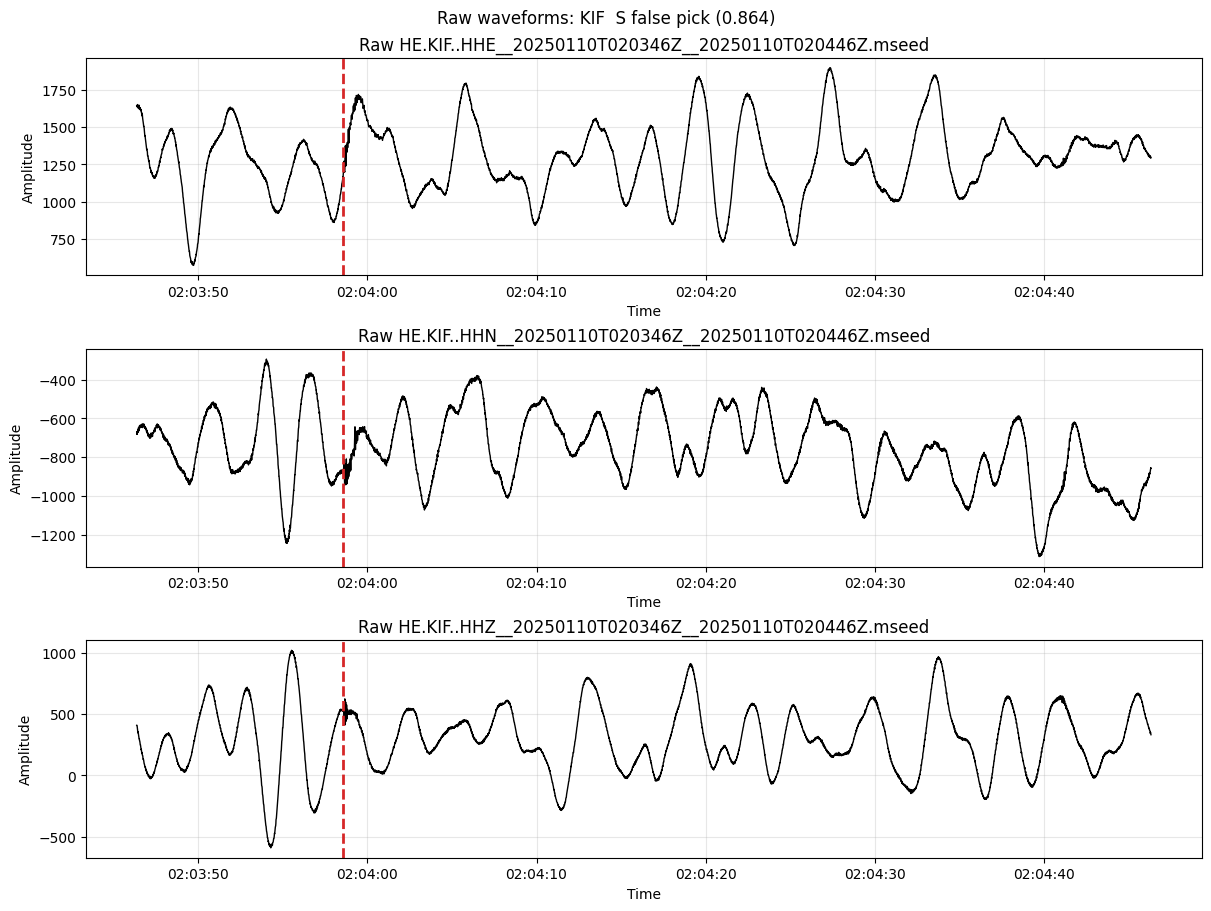

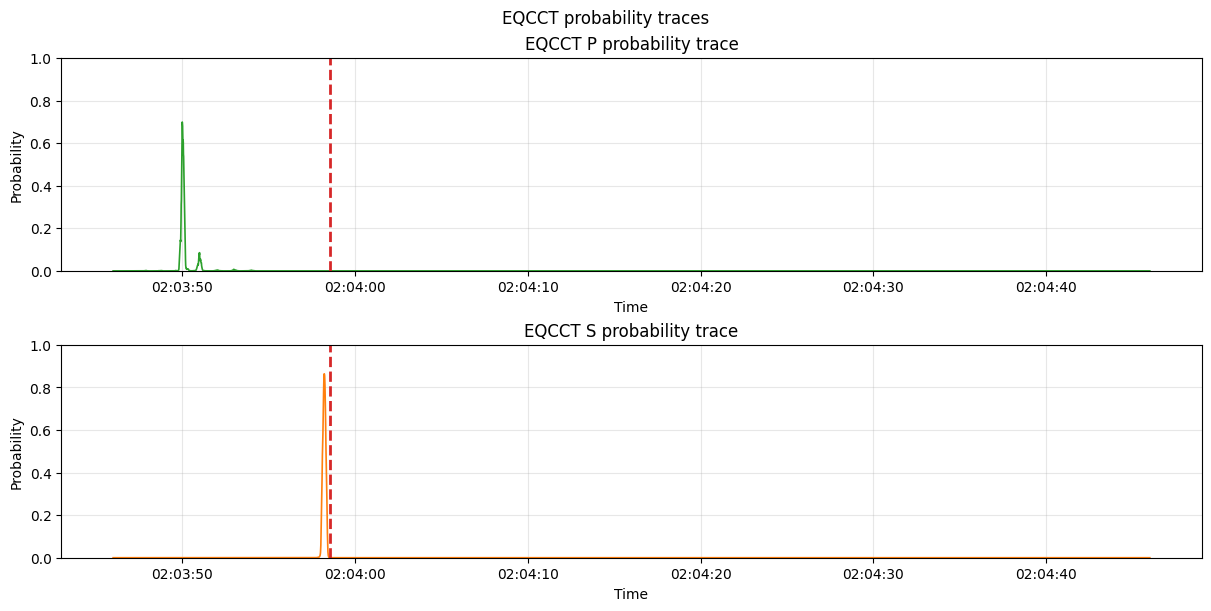

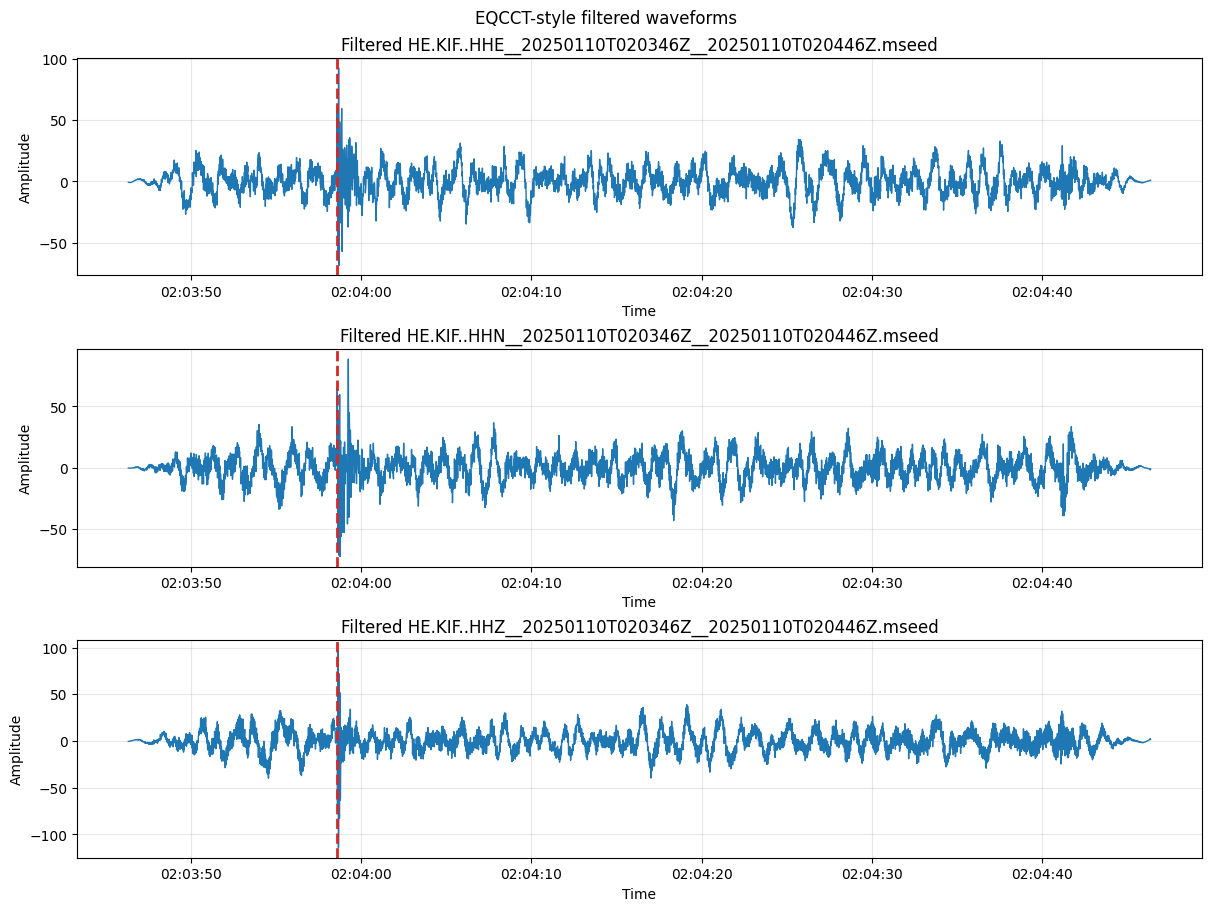

,file_name,network,station,instrument_type,station_lat,station_lon,station_elv,p_arrival_time,p_probability,s_arrival_time,s_probability,start_dt,end_dt
1324,KIF/HE.KIF..HHN__20250110T020346Z__20250110T02...,HE,KIF,0,0,0,0,2025-01-10 02:03:50.410000,0.578,2025-01-10 02:03:58.570000,0.864,2025-01-10 02:03:46,2025-01-10 02:04:46


In [12]:
waveform_root = Path("../data/waveforms_noise_only")
project_root = Path("..").resolve()
models_dir = project_root / "models" / "EQCCT"

# Keep notebook inference on CPU and reduce TensorFlow logging noise.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from eqcctpro.eqcct_tf_models import load_eqcct_model
from obspy import UTCDateTime

def eqcct_filter_trace(trace):
    filtered = trace.copy()
    filtered.detrend("demean")
    max_percentage = 5 / (filtered.stats.delta * filtered.stats.npts)
    filtered.taper(max_percentage=max_percentage, type="cosine")
    filtered.filter("bandpass", freqmin=1.0, freqmax=45.0, corners=2, zerophase=True)
    if filtered.stats.sampling_rate != 100.0:
        filtered.interpolate(100.0, method="linear")
    return filtered

def notebook_normalize(data, mode="std"):
    data = data.copy()
    data -= np.mean(data, axis=0, keepdims=True)
    if mode == "max":
        scale = np.max(data, axis=0, keepdims=True)
    else:
        scale = np.std(data, axis=0, keepdims=True)
    scale[scale == 0] = 1
    return data / scale

def build_eqcct_input_window(waveform_paths, start_dt, duration_seconds=60):
    start_dt = pd.Timestamp(start_dt)
    end_dt = start_dt + pd.Timedelta(seconds=duration_seconds)
    start_utc = UTCDateTime(start_dt.to_pydatetime())
    end_utc = UTCDateTime(end_dt.to_pydatetime())
    traces_by_component = {}
    for path in waveform_paths:
        tr = eqcct_filter_trace(read(str(path))[0])
        traces_by_component[tr.stats.channel[-1]] = tr

    sample = np.zeros((6000, 3), dtype=np.float32)
    component_order = [("E", "1"), ("N", "2"), ("Z",)]
    for col_idx, candidates in enumerate(component_order):
        selected = None
        for code in candidates:
            if code in traces_by_component:
                selected = traces_by_component[code]
                break
        if selected is None:
            continue
        window = selected.copy().slice(start_utc, end_utc)
        data = window.data[:6000]
        if len(data) < 6000:
            data = np.pad(data, (0, 6000 - len(data)))
        sample[:, col_idx] = data
    return notebook_normalize(sample, mode="std").astype(np.float32)

def get_eqcct_probability_traces(waveform_paths, station_name, start_dt):
    global _eqcct_model_cache
    if "_eqcct_model_cache" not in globals():
        _eqcct_model_cache = load_eqcct_model(
            str(models_dir / "test_trainer_024.h5"),
            str(models_dir / "test_trainer_021.h5")
        )

    sample = build_eqcct_input_window(waveform_paths, start_dt)
    predP, predS = _eqcct_model_cache.predict(sample[np.newaxis, :, :], verbose=0)
    prob_times = pd.Timestamp(start_dt) + pd.to_timedelta(np.arange(sample.shape[0]) / 100.0, unit="s")
    return prob_times, predP[0, :, 0], predS[0, :, 0]

def plot_false_pick_waveform(row, phase):
    start_str = pd.Timestamp(row["start_dt"]).strftime("%Y%m%dT%H%M%SZ")
    end_str = pd.Timestamp(row["end_dt"]).strftime("%Y%m%dT%H%M%SZ")
    time_window = f"{start_str}_{end_str}"
    station_name = str(row["station"]).strip()
    file_name = str(row["file_name"]).strip()
    station_from_file = Path(file_name).parts[0] if file_name else station_name
    station_dir = waveform_root / time_window / station_from_file
    waveform_paths = sorted(station_dir.glob("*.mseed"))
    if not waveform_paths and station_from_file != station_name:
        station_dir = waveform_root / time_window / station_name
        waveform_paths = sorted(station_dir.glob("*.mseed"))
    if not waveform_paths:
        raise FileNotFoundError(f"No waveform files found in {station_dir} for row index {row.name}")

    pick_col = f"{phase.lower()}_arrival_time"
    prob_col = f"{phase.lower()}_probability"
    pick_time = pd.to_datetime(row[pick_col]) if pd.notna(row[pick_col]) else None

    raw_traces = [read(str(path))[0] for path in waveform_paths]
    filtered_traces = [eqcct_filter_trace(trace) for trace in raw_traces]
    prob_times, p_prob_trace, s_prob_trace = get_eqcct_probability_traces(waveform_paths, station_name, row["start_dt"])

    fig_raw, axes_raw = plt.subplots(len(raw_traces), 1, figsize=(12, 3 * len(raw_traces)), constrained_layout=True)
    if len(raw_traces) == 1:
        axes_raw = [axes_raw]
    for ax, trace, path in zip(axes_raw, raw_traces, waveform_paths):
        ax.plot(trace.times("matplotlib"), trace.data, linewidth=1, color="black")
        ax.set_title(f"Raw {path.name}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Amplitude")
        ax.grid(alpha=0.3)
        if pick_time is not None:
            ax.axvline(pick_time.to_pydatetime(), color="tab:red", linestyle="--", linewidth=2)
    fig_raw.suptitle(f"Raw waveforms: {row['station']} {phase} false pick ({row[prob_col]:.3f})")
    plt.show()

    fig_prob, axes_prob = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
    axes_prob[0].plot(prob_times, p_prob_trace, linewidth=1.2, color="tab:green")
    axes_prob[0].set_title("EQCCT P probability trace")
    axes_prob[0].set_xlabel("Time")
    axes_prob[0].set_ylabel("Probability")
    axes_prob[0].set_ylim(0, 1)
    axes_prob[0].grid(alpha=0.3)

    axes_prob[1].plot(prob_times, s_prob_trace, linewidth=1.2, color="tab:orange")
    axes_prob[1].set_title("EQCCT S probability trace")
    axes_prob[1].set_xlabel("Time")
    axes_prob[1].set_ylabel("Probability")
    axes_prob[1].set_ylim(0, 1)
    axes_prob[1].grid(alpha=0.3)

    if pick_time is not None:
        axes_prob[0].axvline(pick_time.to_pydatetime(), color="tab:red", linestyle="--", linewidth=2)
        axes_prob[1].axvline(pick_time.to_pydatetime(), color="tab:red", linestyle="--", linewidth=2)
    fig_prob.suptitle("EQCCT probability traces")
    plt.show()

    fig_filtered, axes_filtered = plt.subplots(len(filtered_traces), 1, figsize=(12, 3 * len(filtered_traces)), constrained_layout=True)
    if len(filtered_traces) == 1:
        axes_filtered = [axes_filtered]
    for ax, trace, path in zip(axes_filtered, filtered_traces, waveform_paths):
        ax.plot(trace.times("matplotlib"), trace.data, linewidth=1, color="tab:blue")
        ax.set_title(f"Filtered {path.name}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Amplitude")
        ax.grid(alpha=0.3)
        if pick_time is not None:
            ax.axvline(pick_time.to_pydatetime(), color="tab:red", linestyle="--", linewidth=2)
    fig_filtered.suptitle("EQCCT-style filtered waveforms")
    plt.show()

    display(row.to_frame().T)

p_candidates = combined_df.loc[combined_df["p_probability"].notna()]
s_candidates = combined_df.loc[combined_df["s_probability"].notna()]

# Set these to a row index from combined_df to plot a specific false pick.
# Leave as None to use the highest-probability pick for that phase.
p_plot_index = None
s_plot_index = None
#p_plot_index = 541
#s_plot_index = 674

p_row = combined_df.loc[p_plot_index] if p_plot_index is not None else combined_df.loc[p_candidates["p_probability"].idxmax()]
s_row = combined_df.loc[s_plot_index] if s_plot_index is not None else combined_df.loc[s_candidates["s_probability"].idxmax()]

plot_false_pick_waveform(p_row, "P")
plot_false_pick_waveform(s_row, "S")
